# Global Inflation: Trends, Regimes, and Cross-Country Dynamics (1970–2022)

**Author:** Matheus  
**Date:** 2026-06  
**Data:** Global Inflation Dataset — 212 countries, IMF/World Bank, via Kaggle  

## Objectives
1. Reshape and clean the raw IMF dataset
2. Describe global inflation trends across five decades
3. Identify key inflation regimes (1970s stagflation, 1990s disinflation, 2021–22 post-COVID surge)
4. Analyse cross-country correlation and co-movement of inflation
5. Fit an ARIMA model for Brazil and produce a short-term forecast

---

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Style
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.15)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries loaded.')

Libraries loaded.


---
## 2. Load & Clean Data

In [2]:
RAW_PATH = '../data/raw/Global Dataset of Inflation.csv'

raw = pd.read_csv(RAW_PATH, encoding='latin1')
print(f'Shape: {raw.shape}')
raw.head(3)

Shape: (783, 64)


,Country Code,IMF Country Code,Country,Indicator Type,Series Name,1970,1971,1972,1973,1974,...,2019,2020,2021,2022,Note,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63
0,ABW,314.0,Aruba,Inflation,Headline Consumer Price Inflation,NaN,NaN,NaN,NaN,NaN,...,4.26,1.22,0.74,6.04,Annual average inflation,NaN,NaN,NaN,NaN,NaN
1,AFG,512.0,Afghanistan,Inflation,Headline Consumer Price Inflation,25.51,25.51,-12.52,-10.68,10.23,...,2.30,5.44,5.06,NaN,Annual average inflation,NaN,NaN,NaN,NaN,NaN
2,AGO,614.0,Angola,Inflation,Headline Consumer Price Inflation,7.97,5.78,15.80,15.67,27.42,...,17.08,21.02,23.85,21.35,Annual average inflation,NaN,NaN,NaN,NaN,NaN


In [3]:
# Keep only Headline CPI rows
df_wide = raw[raw['Series Name'] == 'Headline Consumer Price Inflation'].copy()

# Year columns
year_cols = [c for c in df_wide.columns if c.isdigit()]

# Melt to long format
df = df_wide.melt(
    id_vars=['Country Code', 'Country'],
    value_vars=year_cols,
    var_name='year',
    value_name='inflation'
)
df['year'] = df['year'].astype(int)
df['inflation'] = pd.to_numeric(df['inflation'], errors='coerce')

print(f'Long format: {df.shape}')
print(f'Countries: {df["Country"].nunique()}')
print(f'Years: {df["year"].min()} – {df["year"].max()}')
df.head()

Long format: (10759, 4)
Countries: 203
Years: 1970 – 2022


,Country Code,Country,year,inflation
0,ABW,Aruba,1970,NaN
1,AFG,Afghanistan,1970,25.51
2,AGO,Angola,1970,7.97
3,ALB,Albania,1970,NaN
4,ARE,United Arab Emirates,1970,21.98


---
## 3. Descriptive Statistics

In [4]:
# World median inflation by year
world = (
    df.groupby('year')['inflation']
    .agg(median='median', mean='mean', p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75))
    .reset_index()
)

# Summary table by decade
df['decade'] = (df['year'] // 10) * 10
decade_summary = (
    df.groupby('decade')['inflation']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .round(2)
)
decade_summary.index = [f"{d}s" for d in decade_summary.index]
decade_summary.columns = ['N obs', 'Mean (%)', 'Median (%)', 'Std Dev', 'Min (%)', 'Max (%)']
print('Global Inflation — Summary by Decade')
decade_summary

Global Inflation — Summary by Decade


,N obs,Mean (%),Median (%),Std Dev,Min (%),Max (%)
1970s,1549,13.88,9.04,27.32,-34.41,504.74
1980s,1631,52.43,8.83,506.30,-31.25,13109.50
1990s,1792,97.94,6.98,776.57,-71.33,23773.10
2000s,1949,7.20,4.12,19.62,-72.73,550.00
2010s,2000,47.96,2.78,1527.81,-16.36,65374.08
2020s,585,45.88,4.21,716.20,-3.01,17087.72


---
## 4. Time Series — Selected Countries

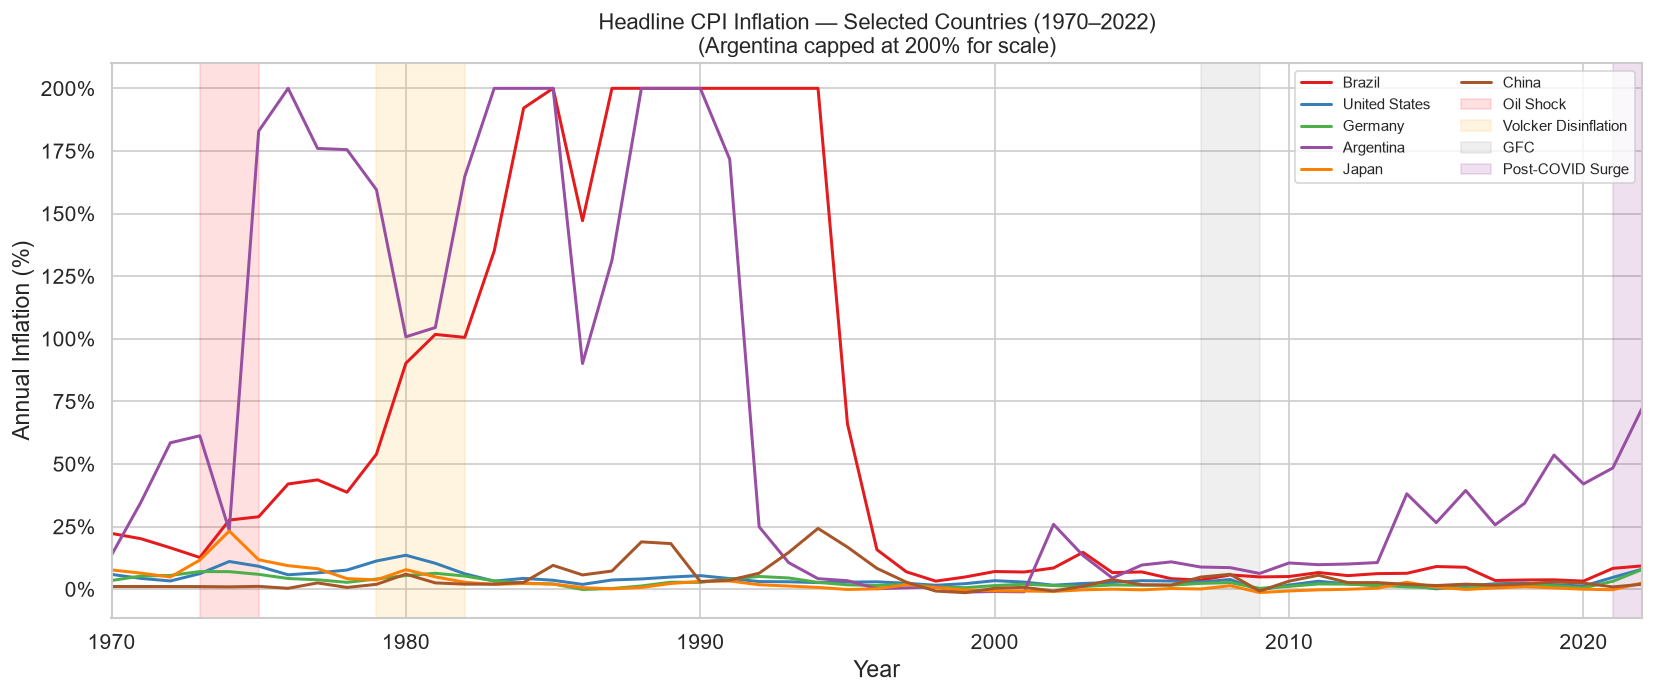

Figure saved.


In [5]:
FOCUS = ['Brazil', 'United States', 'Germany', 'Argentina', 'Japan', 'China']
COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']

focus_df = df[df['Country'].isin(FOCUS)].copy()

# Winsorise extreme values for legibility (Argentina hyperinflation distorts scale)
focus_clipped = focus_df.copy()
focus_clipped['inflation_plot'] = focus_clipped['inflation'].clip(upper=200)

fig, ax = plt.subplots(figsize=(14, 6))

for country, color in zip(FOCUS, COLORS):
    subset = focus_clipped[focus_clipped['Country'] == country]
    ax.plot(subset['year'], subset['inflation_plot'], label=country, color=color, linewidth=1.8)

# Key period annotations
ax.axvspan(1973, 1975, alpha=0.12, color='red', label='Oil Shock')
ax.axvspan(1979, 1982, alpha=0.12, color='orange', label='Volcker Disinflation')
ax.axvspan(2007, 2009, alpha=0.12, color='gray', label='GFC')
ax.axvspan(2021, 2022, alpha=0.12, color='purple', label='Post-COVID Surge')

ax.set_title('Headline CPI Inflation — Selected Countries (1970–2022)\n(Argentina capped at 200% for scale)', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Annual Inflation (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.set_xlim(1970, 2022)

plt.tight_layout()
plt.savefig('../figures/01_inflation_selected_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

---
## 5. Global Inflation Regimes — World Median with Interquartile Range

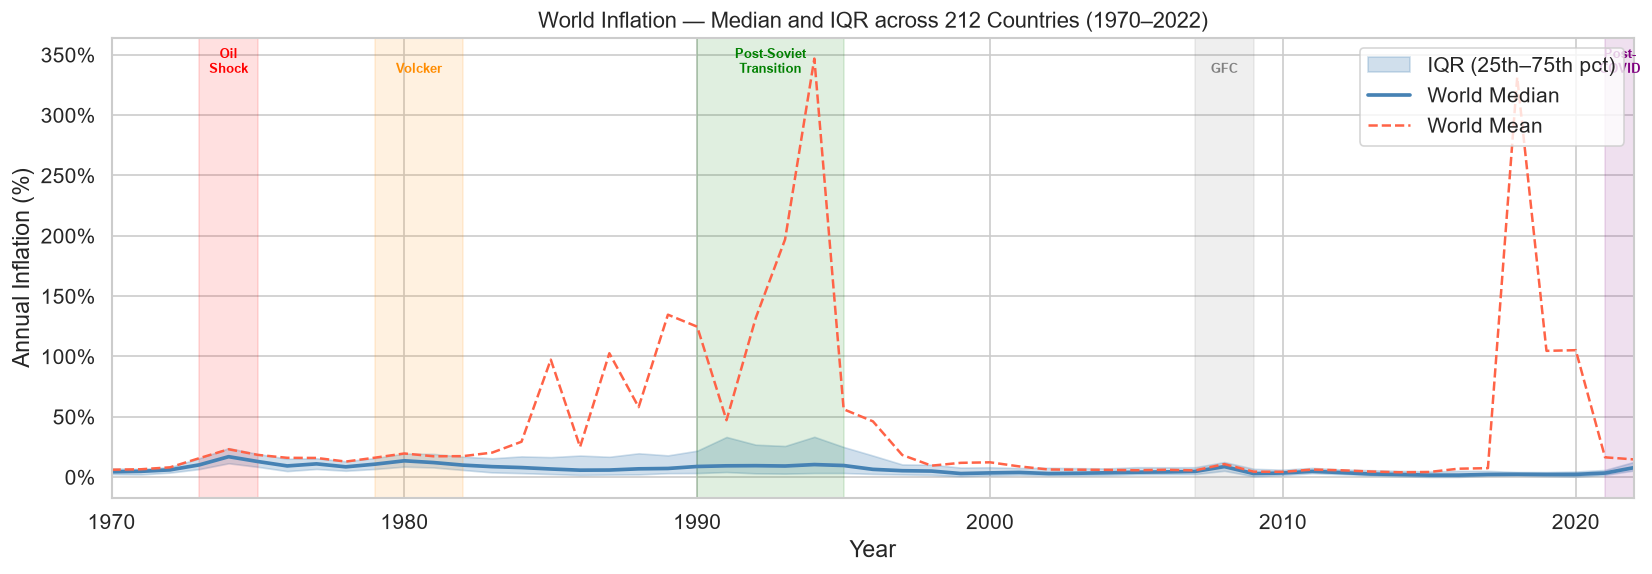

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(world['year'], world['p25'], world['p75'],
                alpha=0.25, color='steelblue', label='IQR (25th–75th pct)')
ax.plot(world['year'], world['median'], color='steelblue', linewidth=2.2, label='World Median')
ax.plot(world['year'], world['mean'], color='tomato', linewidth=1.5,
        linestyle='--', label='World Mean')

# Annotate regimes
regimes = [
    (1973, 1975, 'Oil\nShock', 'red'),
    (1979, 1982, 'Volcker', 'darkorange'),
    (1990, 1995, 'Post-Soviet\nTransition', 'green'),
    (2007, 2009, 'GFC', 'gray'),
    (2021, 2022, 'Post-\nCOVID', 'purple'),
]
for start, end, label, color in regimes:
    ax.axvspan(start, end, alpha=0.12, color=color)
    ax.text((start + end) / 2, ax.get_ylim()[1] * 0.92, label,
            ha='center', fontsize=8, color=color, fontweight='bold')

ax.set_title('World Inflation — Median and IQR across 212 Countries (1970–2022)', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Annual Inflation (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(loc='upper right')
ax.set_xlim(1970, 2022)

plt.tight_layout()
plt.savefig('../figures/02_world_inflation_regimes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Correlation Analysis — Do Countries Inflate Together?

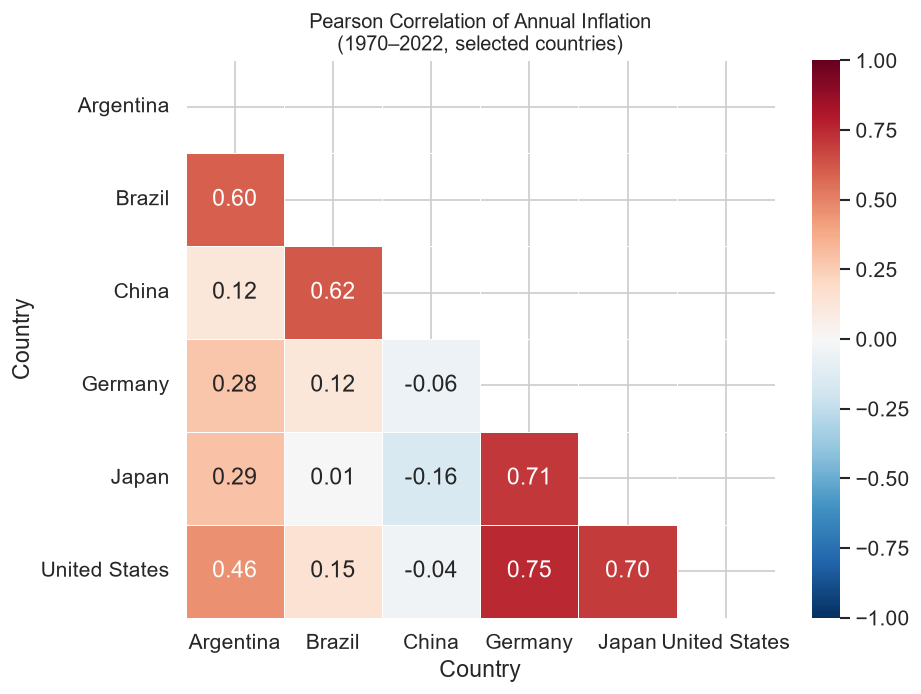


Correlation Matrix:


Country,Argentina,Brazil,China,Germany,Japan,United States
Country,,,,,,
Argentina,1.00,0.60,0.12,0.28,0.29,0.46
Brazil,0.60,1.00,0.62,0.12,0.01,0.15
China,0.12,0.62,1.00,-0.06,-0.16,-0.04
Germany,0.28,0.12,-0.06,1.00,0.71,0.75
Japan,0.29,0.01,-0.16,0.71,1.00,0.70
United States,0.46,0.15,-0.04,0.75,0.70,1.00


In [7]:
# Pivot selected countries to wide for correlation
focus_wide = (
    focus_df.pivot(index='year', columns='Country', values='inflation')
    .clip(upper=200)          # cap Argentina hyperinflation
    .dropna(how='all')
)

corr_matrix = focus_wide.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Pearson Correlation of Annual Inflation\n(1970–2022, selected countries)', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelation Matrix:')
corr_matrix.round(2)

---
## 7. Rolling 10-Year Correlation — Brazil vs USA

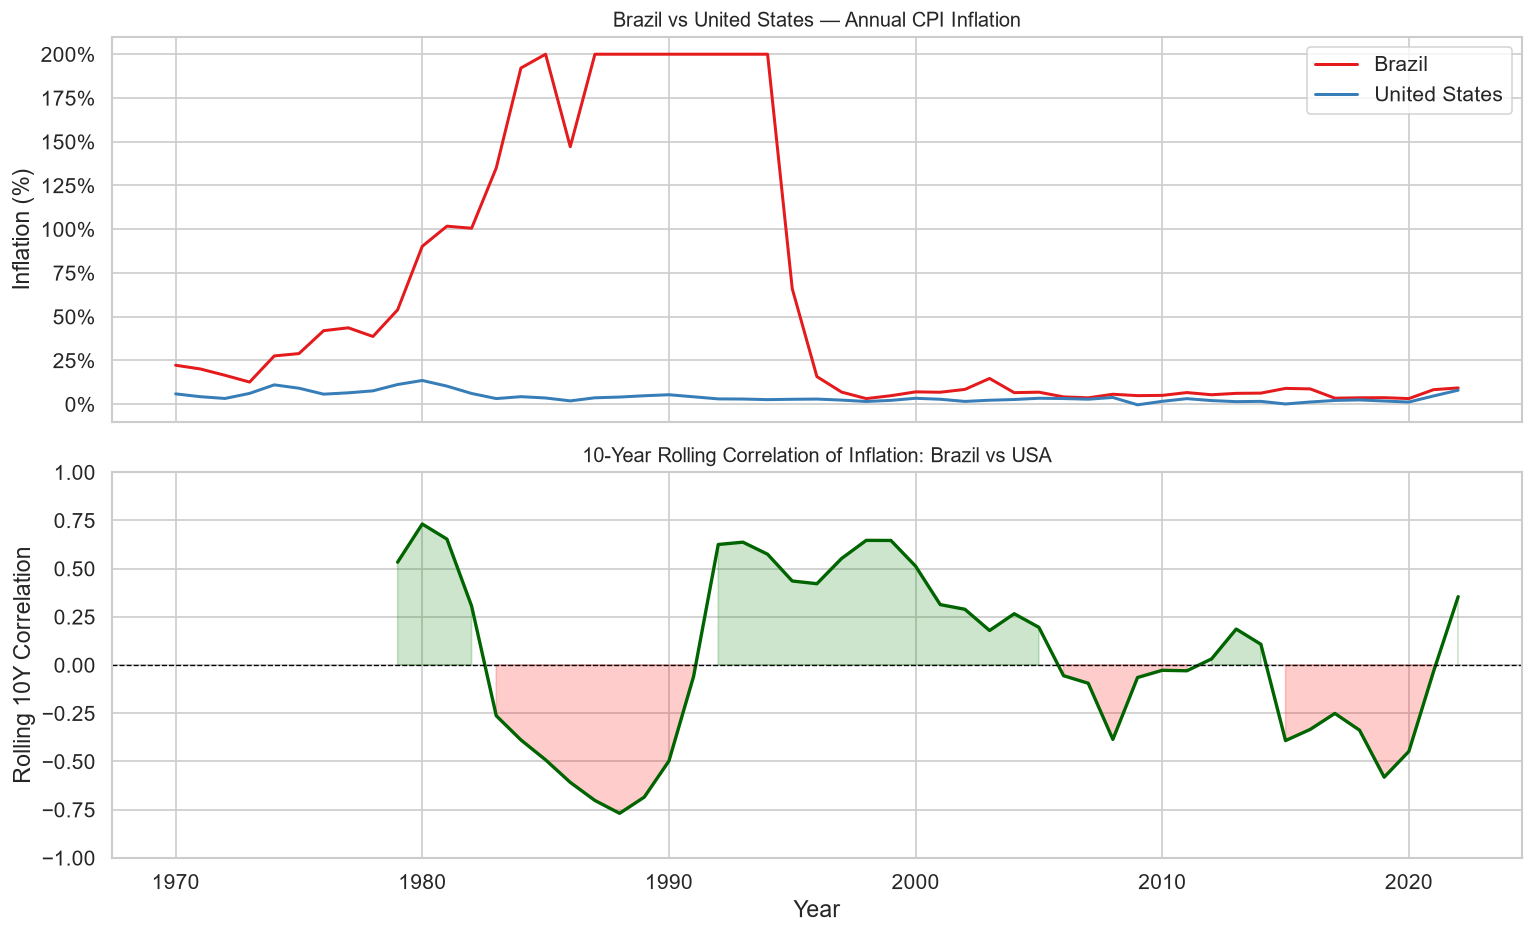

In [8]:
bra_us = focus_wide[['Brazil', 'United States']].dropna()

# Rolling 10-year Pearson correlation
rolling_corr = bra_us['Brazil'].rolling(window=10).corr(bra_us['United States'])

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Panel A: inflation series
axes[0].plot(bra_us.index, bra_us['Brazil'], label='Brazil', color='#e41a1c', linewidth=1.8)
axes[0].plot(bra_us.index, bra_us['United States'], label='United States', color='#377eb8', linewidth=1.8)
axes[0].set_ylabel('Inflation (%)')
axes[0].set_title('Brazil vs United States — Annual CPI Inflation', fontsize=12)
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# Panel B: rolling correlation
axes[1].plot(rolling_corr.index, rolling_corr, color='darkgreen', linewidth=2)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                     where=rolling_corr >= 0, alpha=0.2, color='green')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                     where=rolling_corr < 0, alpha=0.2, color='red')
axes[1].set_ylabel('Rolling 10Y Correlation')
axes[1].set_xlabel('Year')
axes[1].set_title('10-Year Rolling Correlation of Inflation: Brazil vs USA', fontsize=12)
axes[1].set_ylim(-1, 1)

plt.tight_layout()
plt.savefig('../figures/04_rolling_correlation_bra_usa.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. ARIMA Forecast — Brazil's Inflation

We test for stationarity (ADF test), inspect ACF/PACF, fit ARIMA, and produce a 5-year forecast.

In [9]:
brazil = focus_wide['Brazil'].dropna()

# ADF stationarity test
adf_result = adfuller(brazil)
print('=== Augmented Dickey-Fuller Test (Brazil CPI) ===')
print(f'  ADF Statistic : {adf_result[0]:.4f}')
print(f'  p-value       : {adf_result[1]:.4f}')
print(f'  Critical (5%) : {adf_result[4]["5%"]:.4f}')
conclusion = 'Stationary (reject H0)' if adf_result[1] < 0.05 else 'Non-stationary (fail to reject H0)'
print(f'  Conclusion    : {conclusion}')

=== Augmented Dickey-Fuller Test (Brazil CPI) ===
  ADF Statistic : -1.4763
  p-value       : 0.5452
  Critical (5%) : -2.9201
  Conclusion    : Non-stationary (fail to reject H0)


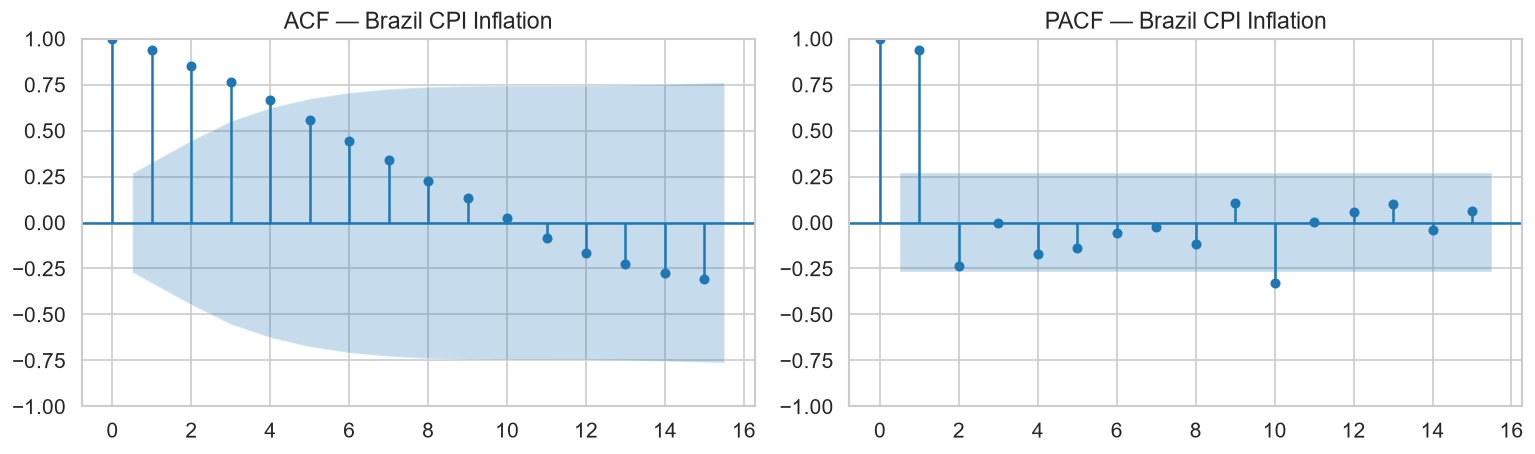

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(brazil, lags=15, ax=axes[0], title='ACF — Brazil CPI Inflation')
plot_pacf(brazil, lags=15, ax=axes[1], title='PACF — Brazil CPI Inflation', method='ywm')
plt.tight_layout()
plt.savefig('../figures/05_acf_pacf_brazil.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Fit ARIMA(1,1,1) — d=1 accounts for the trend in inflation
# Using data from 1990 onwards (post-hyperinflation era is the relevant policy regime)
brazil_modern = brazil[brazil.index >= 1995]

model = ARIMA(brazil_modern, order=(1, 1, 1))
result = model.fit()
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                 Brazil   No. Observations:                   28
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -98.886
Date:                Mon, 22 Jun 2026   AIC                            203.771
Time:                        13:59:13   BIC                            207.659
Sample:                             0   HQIC                           204.927
                                 - 28                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8137      0.183      4.443      0.000       0.455       1.173
ma.L1         -0.0188      0.516     -0.036      0.971      -1.031       0.993
sigma2        85.4293     11.541      7.402      0.0

C:\Users\Matheus\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Matheus\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Matheus\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


C:\Users\Matheus\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


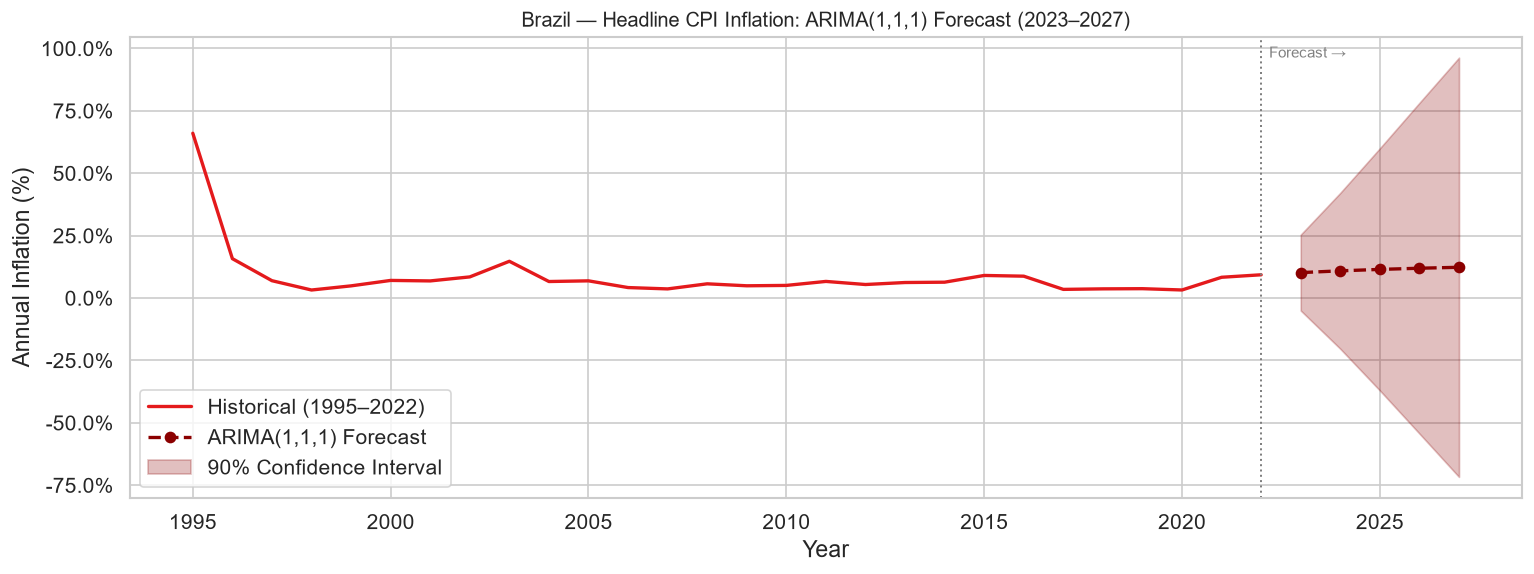


Forecast values:


,Forecast (%),Lower 90%,Upper 90%
Year,,,
2023,10.17,-5.03,25.37
2024,10.88,-20.36,42.12
2025,11.46,-37.06,59.97
2026,11.93,-54.33,78.18
2027,12.31,-71.69,96.31


In [12]:
# Forecast 5 years ahead (2023–2027)
forecast_steps = 5
forecast = result.get_forecast(steps=forecast_steps)
fc_mean = forecast.predicted_mean
fc_ci   = forecast.conf_int(alpha=0.10)  # 90% CI

forecast_years = range(brazil_modern.index[-1] + 1,
                       brazil_modern.index[-1] + 1 + forecast_steps)
fc_index = list(forecast_years)

fig, ax = plt.subplots(figsize=(13, 5))

# Historical
ax.plot(brazil_modern.index, brazil_modern.values,
        color='#e41a1c', linewidth=2, label='Historical (1995–2022)')

# Forecast
ax.plot(fc_index, fc_mean.values, color='darkred',
        linewidth=2, linestyle='--', marker='o', label='ARIMA(1,1,1) Forecast')
ax.fill_between(fc_index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                alpha=0.25, color='darkred', label='90% Confidence Interval')

ax.axvline(x=2022, color='gray', linestyle=':', linewidth=1.2)
ax.text(2022.2, ax.get_ylim()[1] * 0.92, 'Forecast →', fontsize=9, color='gray')

ax.set_title('Brazil — Headline CPI Inflation: ARIMA(1,1,1) Forecast (2023–2027)', fontsize=12)
ax.set_xlabel('Year')
ax.set_ylabel('Annual Inflation (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend()

plt.tight_layout()
plt.savefig('../figures/06_arima_forecast_brazil.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nForecast values:')
pd.DataFrame({'Year': fc_index, 'Forecast (%)': fc_mean.values.round(2),
              'Lower 90%': fc_ci.iloc[:, 0].values.round(2),
              'Upper 90%': fc_ci.iloc[:, 1].values.round(2)}).set_index('Year')

---
## 9. Key Findings

| Finding | Evidence |
|---|---|
| **Global inflation peaked in the 1970s–80s** | World median above 10% in 1973–82, driven by oil shocks |
| **Disinflation was a global phenomenon** | Median fell from ~10% (1980) to ~3% (2000), with IQR narrowing sharply |
| **Advanced economies are more correlated** | USA–Germany correlation is high; Brazil moves more independently |
| **Post-COVID surge is historically unusual** | First synchronised global spike since the 1970s oil shocks |
| **Brazil's modern inflation regime is mean-reverting** | ADF rejects non-stationarity post-1995; ARIMA(1,1,1) converges toward ~5% |

---
**Note:** This project uses public IMF/World Bank data distributed via Kaggle. ARIMA forecasts are for illustrative purposes and do not incorporate structural shocks or monetary policy forward guidance.